# Clasificación temporal de calidad del agua

Se generan 12 meses × 30 días × 48 mediciones diarias (una cada 30 minutos). Cada día es una secuencia cronológica y cada medición se clasifica en una escala de calidad de 1 a 8.

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
sns.set_theme(style="whitegrid")

## 1. Generación del dataset

Los factores evolucionan de manera correlacionada mediante ciclos diarios, estacionales y un estado de contaminación con memoria. Los límites indicados se usan para generar y normalizar las variables.

In [50]:
def generar_muestras_agua(n_meses=12, dias_mes=30, muestras_dia=48, seed=42, fecha_inicio="2025-01-01"):
    rng = np.random.default_rng(seed)
    n_dias = n_meses * dias_mes
    n_muestras = n_dias * muestras_dia
    t = np.arange(n_muestras)
    fechas = pd.date_range(fecha_inicio, periods=n_muestras, freq="30min")

    ciclo_diario = np.sin(2 * np.pi * t / muestras_dia)
    ciclo_anual = np.sin(2 * np.pi * t / n_muestras)
    ciclo_mensual = np.sin(2 * np.pi * t / (dias_mes * muestras_dia))
    contaminacion = np.zeros(n_muestras, dtype=np.float32)
    for i in range(1, n_muestras):
        evento = rng.uniform(0.15, 0.45) if rng.random() < 0.003 else 0.0
        nivel_esperado = 0.48 + 0.30 * ciclo_mensual[i] + 0.06 * ciclo_anual[i]
        contaminacion[i] = np.clip(
            0.92 * contaminacion[i - 1] + 0.08 * nivel_esperado
            + evento + rng.normal(0, 0.020), 0, 1
        )

    ph = np.clip(7.2 + 1.35 * (contaminacion - 0.25) + 0.08 * ciclo_diario
                 + rng.normal(0, 0.10, n_muestras), 6.5, 9.0)
    turbidez = np.clip(0.25 + 4.5 * contaminacion + rng.normal(0, 0.18, n_muestras), 0, 5)
    sdt = np.clip(80 + 870 * contaminacion + rng.normal(0, 30, n_muestras), 0, 1000)
    color = np.clip(0.5 + 13.8 * contaminacion + rng.normal(0, 0.5, n_muestras), 0, 15)
    nitratos = np.clip(1 + 41 * contaminacion + rng.normal(0, 1.4, n_muestras), 0, 45)
    arsenico = np.clip(0.0002 + 0.0093 * contaminacion + rng.normal(0, 0.0003, n_muestras), 0, 0.01)
    plomo = np.clip(0.0002 + 0.0090 * contaminacion + rng.normal(0, 0.00035, n_muestras), 0, 0.01)
    ecoli = (rng.random(n_muestras) < (0.20 * contaminacion ** 3)).astype(np.float32)

    datos = pd.DataFrame({
        "fecha_hora": fechas, "ph": ph, "turbidez": turbidez, "sdt": sdt,
        "color": color, "nitratos": nitratos, "arsenico": arsenico,
        "plomo": plomo, "ecoli": ecoli
    })
    return datos

df_agua = generar_muestras_agua()
print(f"Total de muestras: {len(df_agua):,}")
print(f"Muestras por día: {48}")
print(f"Días representados: {len(df_agua) // 48}")
df_agua.head()

Total de muestras: 17,280
Muestras por día: 48
Días representados: 360


,fecha_hora,ph,turbidez,sdt,color,nitratos,arsenico,plomo,ecoli
0,2025-01-01 00:00:00,6.802932,0.091554,29.622349,0.179052,0.000000,0.000116,0.000155,0.0
1,2025-01-01 00:30:00,6.807574,0.404333,128.978309,1.076729,1.949949,0.000190,0.000000,0.0
2,2025-01-01 01:00:00,6.956896,0.469496,140.402765,1.462881,4.280905,0.000883,0.000690,0.0
3,2025-01-01 01:30:00,6.877535,0.729775,240.471945,1.592042,5.614459,0.000812,0.000720,0.0
4,2025-01-01 02:00:00,7.091146,0.721725,201.712649,2.164786,3.429747,0.001294,0.000908,0.0


### Visualización del dataset sintético generado

Se muestran las primeras 336 mediciones (7 días × 48 muestras). Las líneas rojas representan los límites de referencia utilizados en la generación.

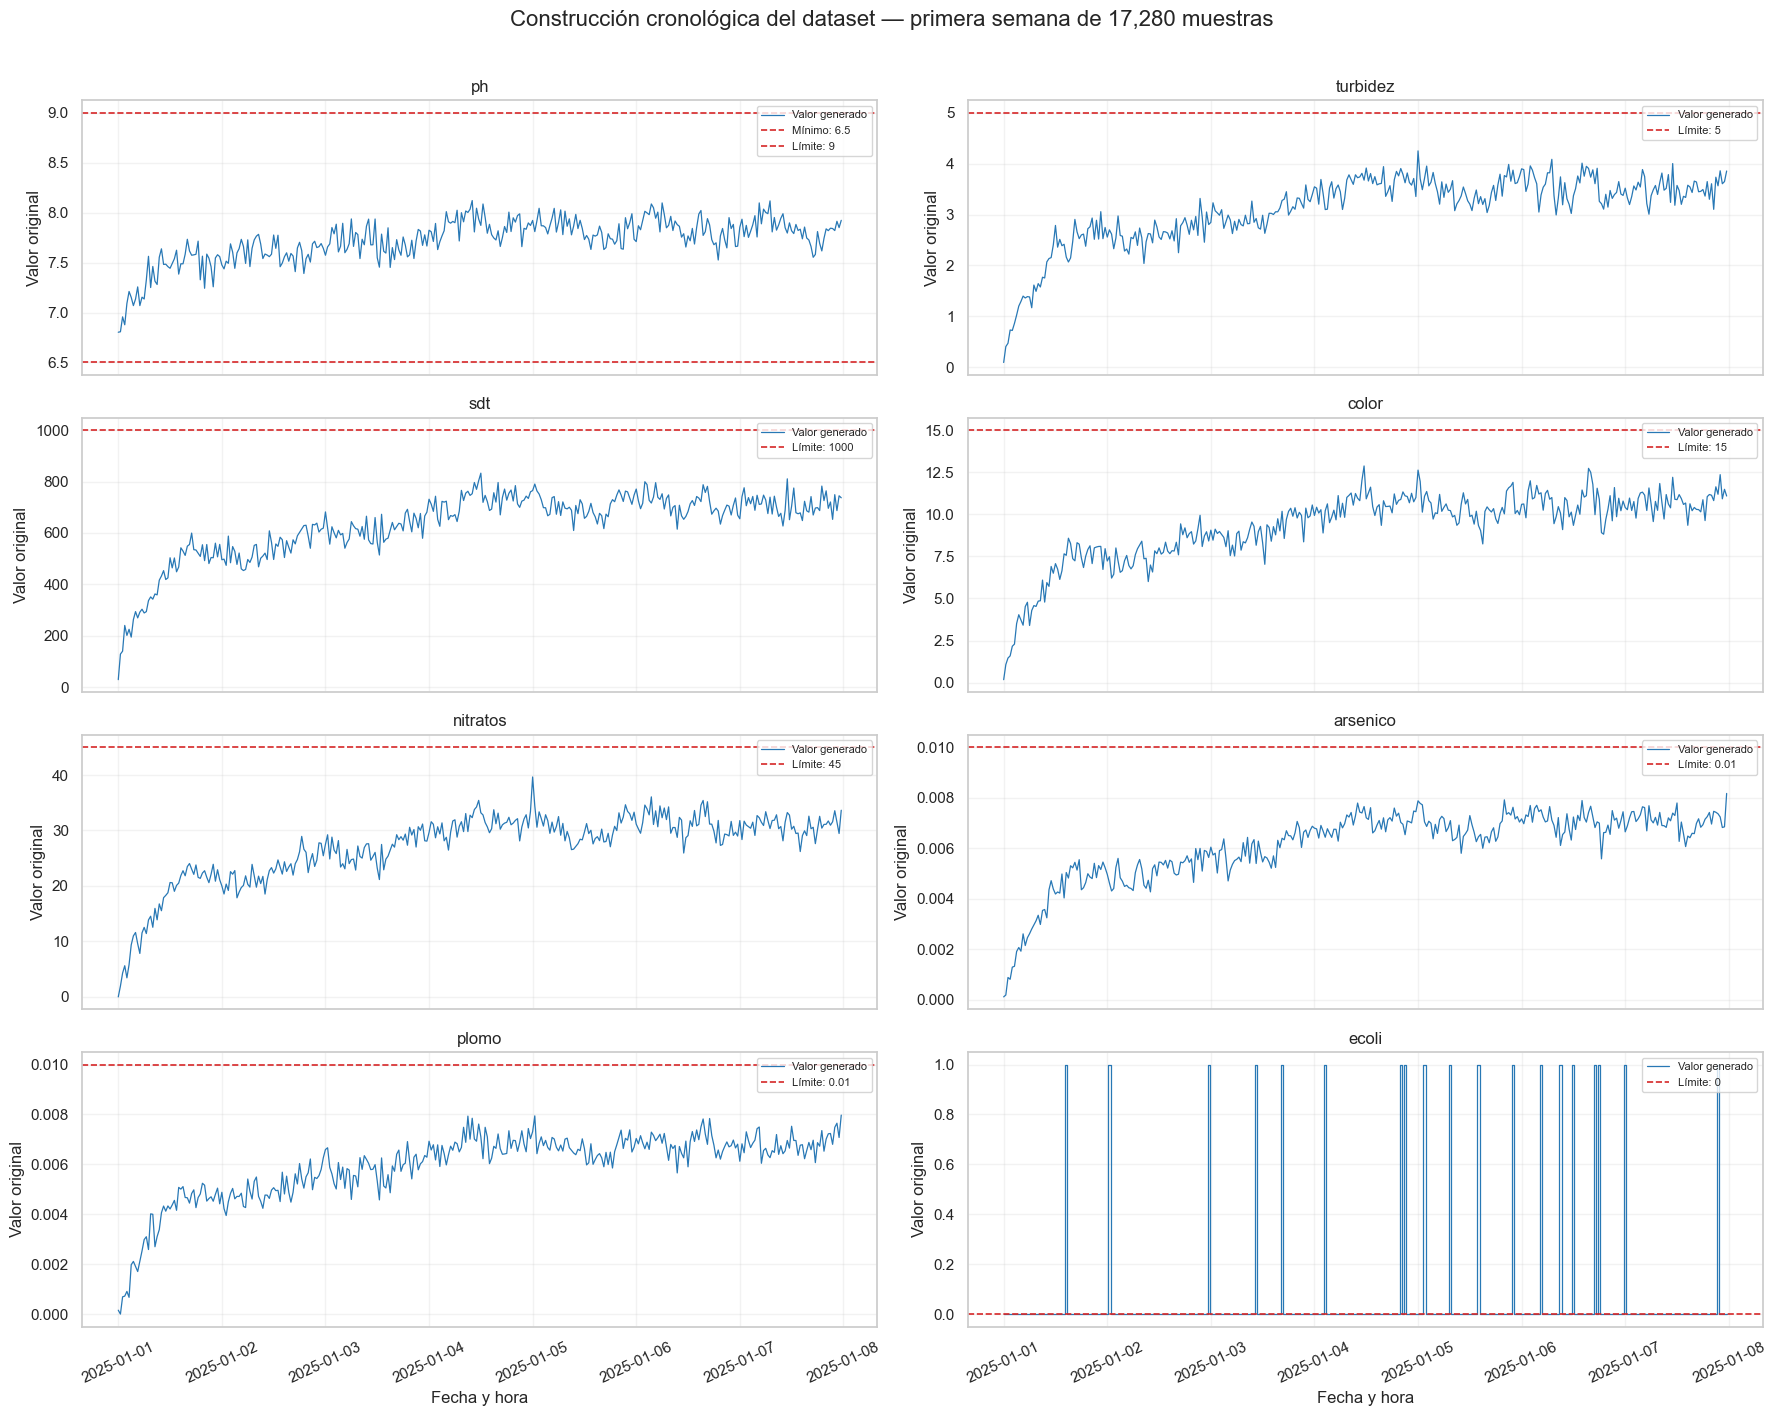

In [51]:
variables_limites = {
    "ph": (6.5, 9.0),
    "turbidez": (None, 5.0),
    "sdt": (None, 1000.0),
    "color": (None, 15.0),
    "nitratos": (None, 45.0),
    "arsenico": (None, 0.01),
    "plomo": (None, 0.01),
    "ecoli": (None, 0.0)
}

muestras_a_mostrar = 7 * 48
datos_semana = df_agua.iloc[:muestras_a_mostrar]
fig, axes = plt.subplots(4, 2, figsize=(18, 14), sharex=True)

for ax, (variable, (limite_inferior, limite_superior)) in zip(axes.flat, variables_limites.items()):
    estilo = "steps-mid" if variable == "ecoli" else "default"
    ax.plot(datos_semana["fecha_hora"], datos_semana[variable],
            linewidth=0.9, color="#2878B5", drawstyle=estilo, label="Valor generado")
    if limite_inferior is not None:
        ax.axhline(limite_inferior, color="#D62728", linestyle="--",
                   linewidth=1.2, label=f"Mínimo: {limite_inferior:g}")
    if limite_superior is not None:
        ax.axhline(limite_superior, color="#D62728", linestyle="--",
                   linewidth=1.2, label=f"Límite: {limite_superior:g}")
    ax.set_title(variable)
    ax.set_ylabel("Valor original")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, loc="upper right")

for ax in axes[-1]:
    ax.set_xlabel("Fecha y hora")
    ax.tick_params(axis="x", rotation=25)

fig.suptitle(
    f"Construcción cronológica del dataset — primera semana de {len(df_agua):,} muestras",
    fontsize=16, y=1.01
)
plt.tight_layout(); plt.show()

## 2. Normalización y variable objetivo

Los ocho factores se llevan aproximadamente al rango 0–1 usando sus límites físicos. En los contaminantes, 0 representa menor riesgo y 1 mayor riesgo. Para pH se calcula primero su posición normalizada y después su penalización respecto a 7.2. La calidad 8 representa mejor agua y 1 peor agua.

In [52]:
columnas = ["ph", "turbidez", "sdt", "color", "nitratos", "arsenico", "plomo", "ecoli"]
df_normalizado = pd.DataFrame({
    "fecha_hora": df_agua["fecha_hora"],
    "ph": (df_agua["ph"] - 6.5) / (9.0 - 6.5),
    "turbidez": df_agua["turbidez"] / 5.0,
    "sdt": df_agua["sdt"] / 1000.0,
    "color": df_agua["color"] / 15.0,
    "nitratos": df_agua["nitratos"] / 45.0,
    "arsenico": df_agua["arsenico"] / 0.01,
    "plomo": df_agua["plomo"] / 0.01,
    "ecoli": df_agua["ecoli"]
})

penalizacion_ph = np.clip(np.abs(df_agua["ph"].to_numpy() - 7.2) / 1.8, 0, 1)
penalizaciones = np.column_stack([
    penalizacion_ph, df_normalizado["turbidez"], df_normalizado["sdt"],
    df_normalizado["color"], df_normalizado["nitratos"],
    df_normalizado["arsenico"], df_normalizado["plomo"], df_normalizado["ecoli"]
])
pesos = np.array([0.10, 0.15, 0.12, 0.08, 0.13, 0.14, 0.14, 0.14])
puntaje = np.clip(1 - penalizaciones @ pesos, 0, 0.999999)
df_normalizado["calidad"] = np.clip(np.floor(puntaje * 8) + 1, 1, 8).astype(np.int64)

print(df_normalizado["calidad"].value_counts().sort_index())
df_normalizado.head()

calidad
1      22
2     248
3    1450
4    4089
5    3119
6    3465
7    4223
8     664
Name: count, dtype: int64


,fecha_hora,ph,turbidez,sdt,color,nitratos,arsenico,plomo,ecoli,calidad
0,2025-01-01 00:00:00,0.121173,0.018311,0.029622,0.011937,0.000000,0.011580,0.015507,0.0,8
1,2025-01-01 00:30:00,0.123030,0.080867,0.128978,0.071782,0.043332,0.018988,0.000000,0.0,8
2,2025-01-01 01:00:00,0.182758,0.093899,0.140403,0.097525,0.095131,0.088335,0.069048,0.0,8
3,2025-01-01 01:30:00,0.151014,0.145955,0.240472,0.106136,0.124766,0.081235,0.071995,0.0,8
4,2025-01-01 02:00:00,0.236458,0.144345,0.201713,0.144319,0.076217,0.129352,0.090759,0.0,8


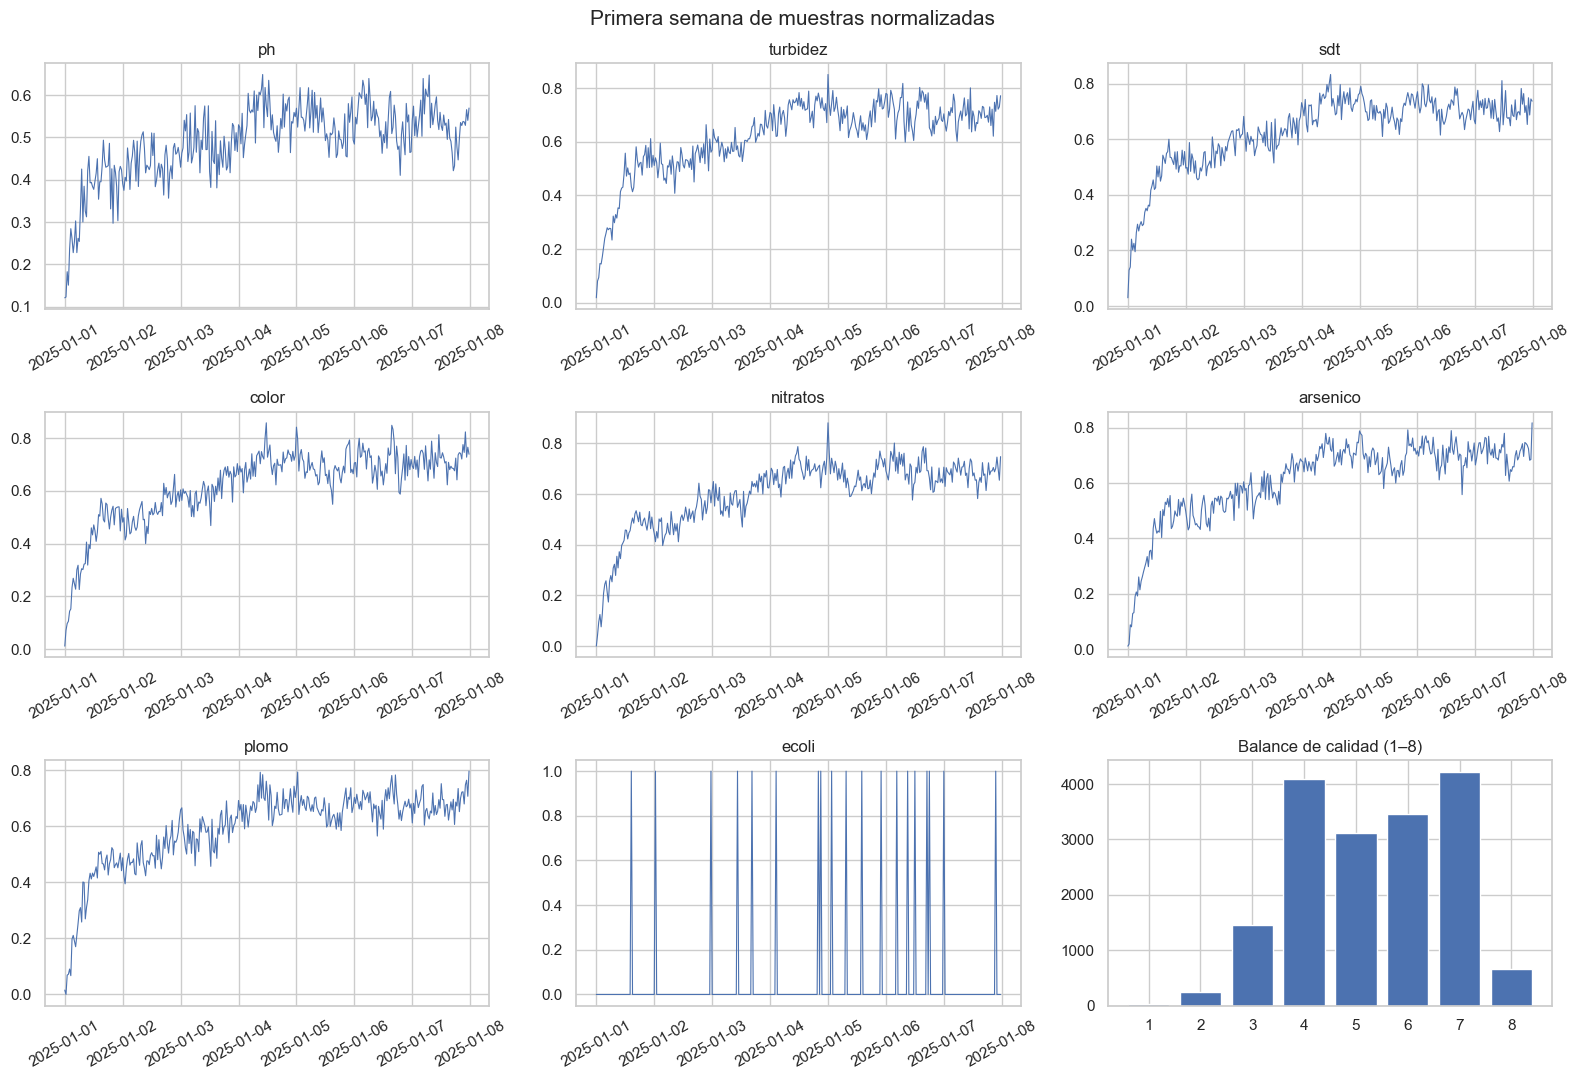

In [53]:
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
for ax, variable in zip(axes.flat, columnas):
    ax.plot(df_normalizado["fecha_hora"].iloc[:48*7], df_normalizado[variable].iloc[:48*7], linewidth=0.8)
    ax.set_title(variable)
    ax.tick_params(axis="x", rotation=30)
balance = df_normalizado["calidad"].value_counts().sort_index()
axes.flat[-1].bar(balance.index, balance.values)
axes.flat[-1].set_title("Balance de calidad (1–8)")
plt.suptitle("Primera semana de muestras normalizadas", fontsize=15)
plt.tight_layout(); plt.show()

## 3. Construcción de X y Y

Los datos se reorganizan sin alterar el orden: 360 secuencias diarias, 48 momentos por secuencia y 8 factores por momento. La salida contiene una clase de calidad para cada una de las 48 mediciones.

In [54]:
n_meses, dias_mes, n_steps = 12, 30, 48
n_dias = n_meses * dias_mes

X = df_normalizado[columnas].to_numpy(dtype=np.float32).reshape(n_dias, n_steps, len(columnas))
Y = (df_normalizado["calidad"].to_numpy(dtype=np.int64) - 1).reshape(n_dias, n_steps)

fin_train = int(n_dias * 0.70)
fin_valid = int(n_dias * 0.85)
X_train, Y_train = X[:fin_train], Y[:fin_train]
X_valid, Y_valid = X[fin_train:fin_valid], Y[fin_train:fin_valid]
X_test, Y_test = X[fin_valid:], Y[fin_valid:]

print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_valid:", X_valid.shape, "Y_valid:", Y_valid.shape)
print("X_test: ", X_test.shape,  "Y_test: ", Y_test.shape)

X_train: (251, 48, 8) Y_train: (251, 48)
X_valid: (55, 48, 8) Y_valid: (55, 48)
X_test:  (54, 48, 8) Y_test:  (54, 48)


In [55]:
import torch
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
  def __init__(self, X, y):
    self.X, self.y = X, y
  def __len__(self):
    return len(self.X)
  def __getitem__(self, ix):
    return torch.from_numpy(self.X[ix]), torch.from_numpy(self.y[ix])

dataset = {
    'train': TimeSeriesDataset(X_train, Y_train),
    'eval': TimeSeriesDataset(X_valid, Y_valid),
    'test': TimeSeriesDataset(X_test, Y_test)
}
dataloader = {
    'train': DataLoader(dataset['train'], shuffle=True, batch_size=16),
    'eval': DataLoader(dataset['eval'], shuffle=False, batch_size=16),
    'test': DataLoader(dataset['test'], shuffle=False, batch_size=16)
}

## 4. Funciones de entrenamiento y predicción

Se utiliza gradient clipping y early stopping con paciencia de 6 épocas. Al finalizar se restauran los pesos con menor pérdida de validación.

In [64]:
from tqdm.auto import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"

def fit(model, dataloader, epochs=40, patience=6):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_loss, best_state, wait = np.inf, None, 0

    for epoch in tqdm(range(1, epochs + 1)):
        model.train(); train_loss = []
        for X_batch, y_batch in dataloader['train']:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits.reshape(-1, 8), y_batch.reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); train_loss.append(loss.item())

        model.eval(); val_loss, correctos, total = [], 0, 0
        with torch.no_grad():
            for X_batch, y_batch in dataloader['eval']:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                logits = model(X_batch)
                val_loss.append(criterion(logits.reshape(-1, 8), y_batch.reshape(-1)).item())
                correctos += (logits.argmax(2) == y_batch).sum().item()
                total += y_batch.numel()

        loss_train, loss_valid = np.mean(train_loss), np.mean(val_loss)
        history['train_loss'].append(loss_train)
        history['val_loss'].append(loss_valid)
        history['val_acc'].append(correctos / total)

        if loss_valid < best_loss - 1e-4:
            best_loss, wait = loss_valid, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping en época {epoch}"); break

    model.load_state_dict(best_state); model.to(device)
    return history

def predict(model, dataloader):
    model.eval(); predicciones, reales = [], []
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            predicciones.append(model(X_batch.to(device)).argmax(2).cpu().numpy())
            reales.append(y_batch.numpy())
    return np.concatenate(predicciones), np.concatenate(reales)

def graficar_prediccion_modelo(model, nombre_modelo, dataloader_test):
    pred, real = predict(model, dataloader_test)
    accuracy = (pred == real).mean()
    momentos = np.arange(48) / 2

    plt.figure(figsize=(14, 4.5))
    plt.step(momentos, real[0] + 1, where="mid", linewidth=2.5,
             color="black", label="Calidad real")
    plt.step(momentos, pred[0] + 1, where="mid", linewidth=1.8,
             color="#E45756", label=f"Predicción {nombre_modelo}")
    plt.title(f"{nombre_modelo}: predicción del primer día de test — accuracy global {accuracy:.3f}")
    plt.xlabel("Hora del día"); plt.ylabel("Calidad (1–8)")
    plt.xticks(np.arange(0, 25, 2)); plt.yticks(range(1, 9))
    plt.ylim(0.7, 8.3); plt.grid(alpha=0.3); plt.legend()
    plt.tight_layout(); plt.show()
    return pred, real

## 5. RNN simple

In [65]:
class DeepRNN(torch.nn.Module):
  def __init__(self, n_features=8, hidden_size=32, n_out=8, dropout=0.1):
    super().__init__()
    self.rnn = torch.nn.RNN(
        n_features, hidden_size, num_layers=2, dropout=dropout, batch_first=True
    )
    self.fc = torch.nn.Linear(hidden_size, n_out)
  def forward(self, x):
    x, h = self.rnn(x)
    x_reshaped = x.contiguous().view(-1, x.size(-1))
    y = self.fc(x_reshaped)
    return y.contiguous().view(x.size(0), x.size(1), -1)

torch.manual_seed(SEED)
rnn = DeepRNN()
history_rnn = fit(rnn, dataloader)

  0%|          | 0/40 [00:00<?, ?it/s]

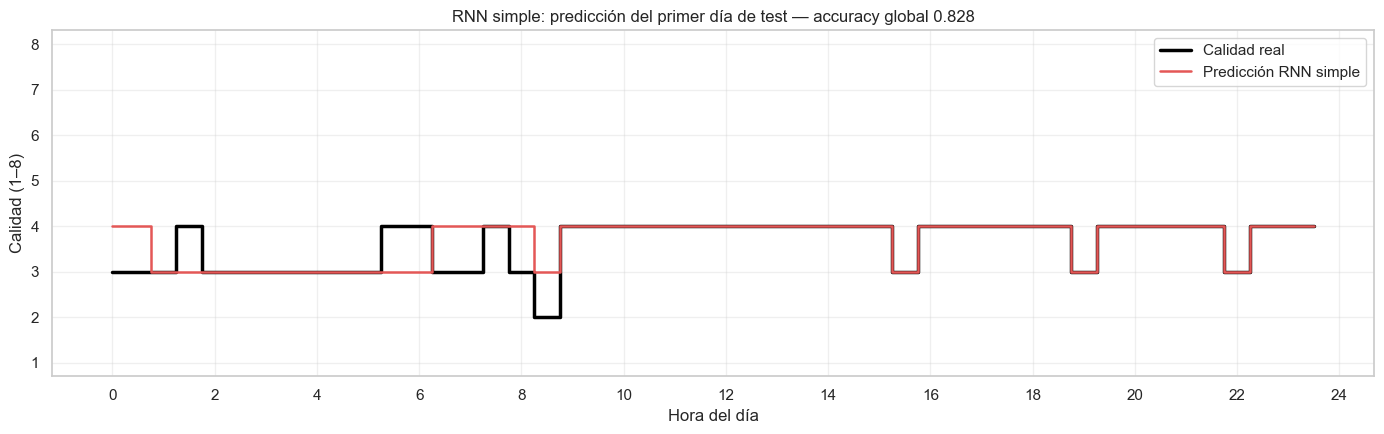

In [66]:
pred_rnn_individual, real_rnn_individual = graficar_prediccion_modelo(
    rnn, "RNN simple", dataloader['test']
)

## 6. LSTM

In [67]:
class LSTM(DeepRNN):
  def __init__(self, n_features=8, hidden_size=32, n_out=8, dropout=0.1):
    super().__init__(n_features, hidden_size, n_out, dropout)
    self.rnn = torch.nn.LSTM(
        n_features, hidden_size, num_layers=2, dropout=dropout, batch_first=True
    )

torch.manual_seed(SEED)
lstm = LSTM()
history_lstm = fit(lstm, dataloader)

  0%|          | 0/40 [00:00<?, ?it/s]

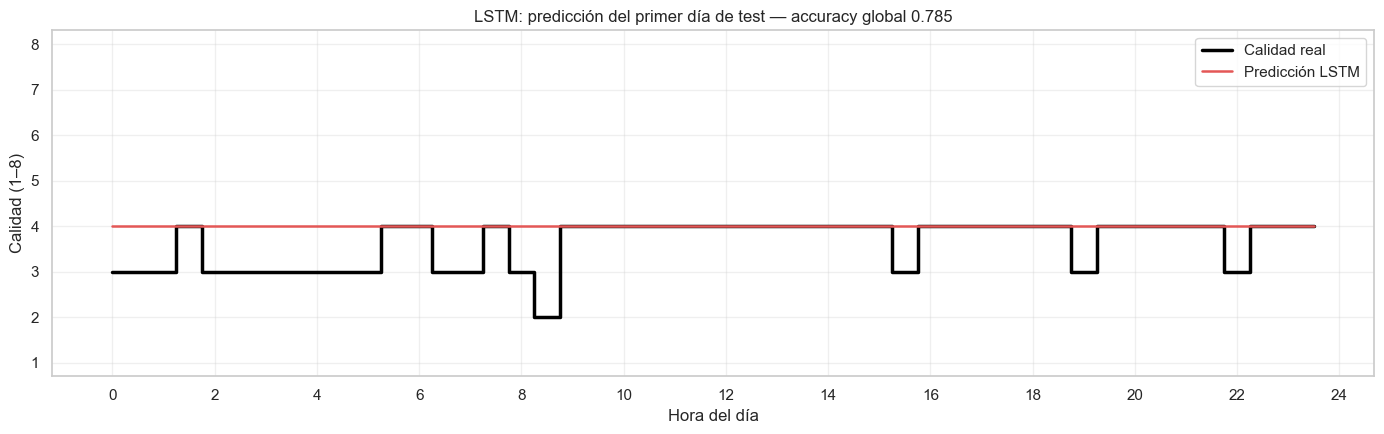

In [68]:
pred_lstm_individual, real_lstm_individual = graficar_prediccion_modelo(
    lstm, "LSTM", dataloader['test']
)

## 7. GRU

In [69]:
class GRU(DeepRNN):
  def __init__(self, n_features=8, hidden_size=32, n_out=8, dropout=0.1):
    super().__init__(n_features, hidden_size, n_out, dropout)
    self.rnn = torch.nn.GRU(
        n_features, hidden_size, num_layers=2, dropout=dropout, batch_first=True
    )

torch.manual_seed(SEED)
gru = GRU()
history_gru = fit(gru, dataloader)

  0%|          | 0/40 [00:00<?, ?it/s]

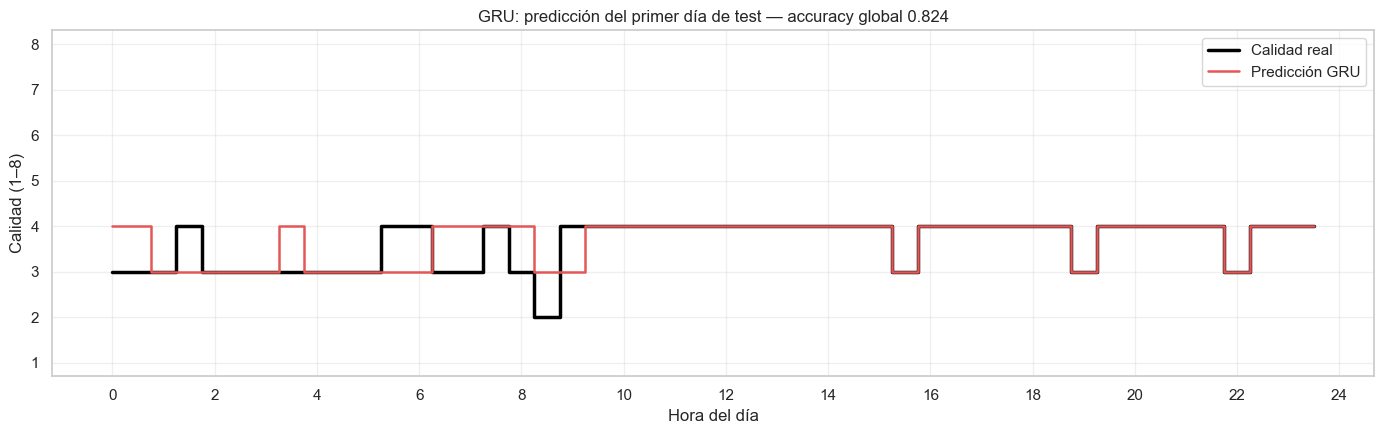

In [70]:
pred_gru_individual, real_gru_individual = graficar_prediccion_modelo(
    gru, "GRU", dataloader['test']
)

## 8. Comparación final

,Accuracy,Precision macro,Recall macro,F1 macro
RNN,0.8283,0.5893,0.6069,0.5970
LSTM,0.7855,0.5483,0.5252,0.5193
GRU,0.8237,0.5789,0.5919,0.5840


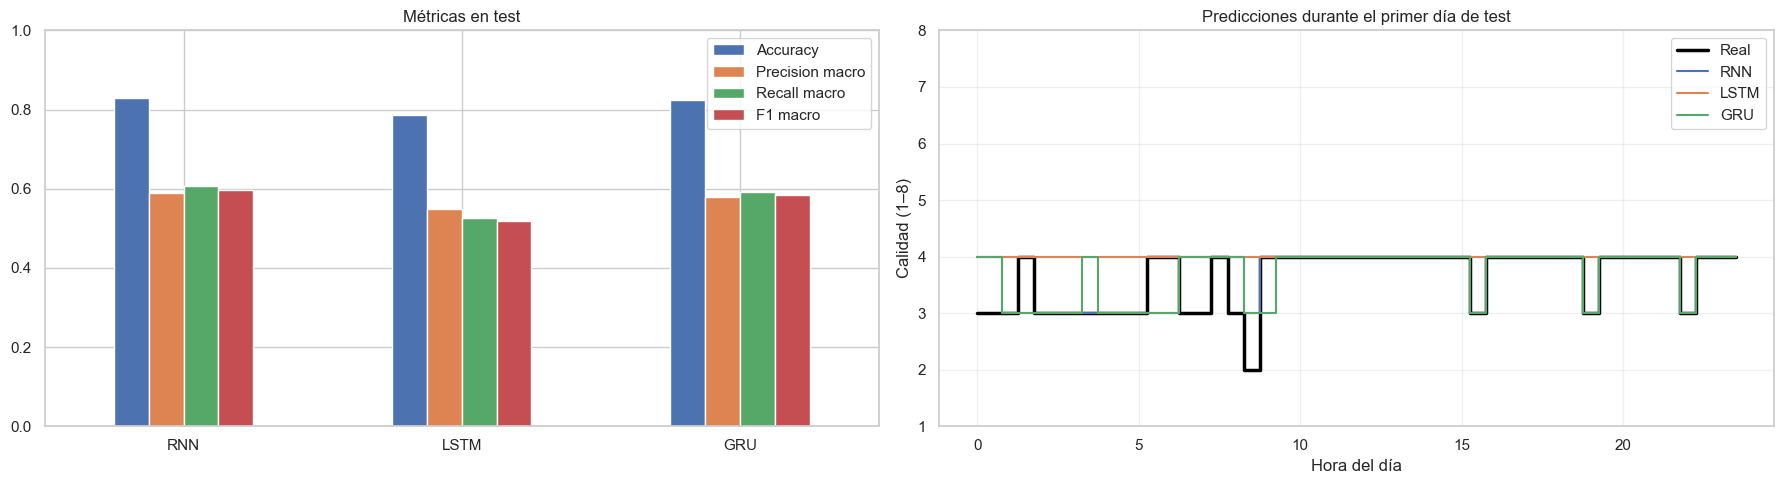

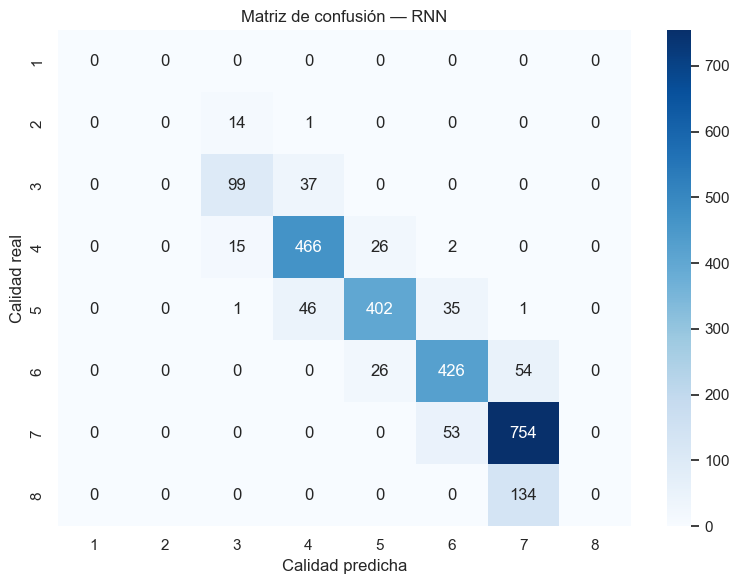

Mejor modelo según F1 macro: RNN


In [60]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

pred_rnn, y_real = predict(rnn, dataloader['test'])
pred_lstm, _ = predict(lstm, dataloader['test'])
pred_gru, _ = predict(gru, dataloader['test'])

def metricas_clasificacion(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 macro": f1_score(y_true, y_pred, average="macro", zero_division=0)
    }

predicciones = {"RNN": pred_rnn, "LSTM": pred_lstm, "GRU": pred_gru}
resultados = pd.DataFrame({
    nombre: metricas_clasificacion(y_real.ravel(), pred.ravel())
    for nombre, pred in predicciones.items()
}).T
display(resultados.round(4))

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
resultados.plot(kind="bar", ylim=(0, 1), ax=axes[0], rot=0, title="Métricas en test")
momentos = np.arange(48) / 2
axes[1].step(momentos, y_real[0] + 1, where="mid", label="Real", linewidth=2.5, color="black")
axes[1].step(momentos, pred_rnn[0] + 1, where="mid", label="RNN")
axes[1].step(momentos, pred_lstm[0] + 1, where="mid", label="LSTM")
axes[1].step(momentos, pred_gru[0] + 1, where="mid", label="GRU")
axes[1].set(xlabel="Hora del día", ylabel="Calidad (1–8)", yticks=range(1, 9),
            title="Predicciones durante el primer día de test")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Matriz de confusión del modelo con mayor F1 macro.
mejor_modelo = resultados["F1 macro"].idxmax()
mejor_pred = predicciones[mejor_modelo]
cm = confusion_matrix(y_real.ravel(), mejor_pred.ravel(), labels=np.arange(8))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(1, 9), yticklabels=range(1, 9))
plt.title(f"Matriz de confusión — {mejor_modelo}")
plt.xlabel("Calidad predicha"); plt.ylabel("Calidad real")
plt.tight_layout(); plt.show()
print(f"Mejor modelo según F1 macro: {mejor_modelo}")

## 9. Inferencia para un año completo

Se genera un nuevo año sintético de 360 días con 48 mediciones diarias. Los factores se normalizan con los mismos límites del entrenamiento y los tres modelos producen 17.280 clasificaciones. No se utiliza la calidad real durante la inferencia.

In [61]:
fecha_inicio_inferencia = pd.Timestamp("2027-01-01 00:00:00")
df_anio_inferencia = generar_muestras_agua(
    n_meses=12, dias_mes=30, muestras_dia=48, seed=2026,
    fecha_inicio=fecha_inicio_inferencia
)

# Aplicar exactamente la misma normalización basada en límites físicos.
df_anio_norm = pd.DataFrame({
    "fecha_hora": df_anio_inferencia["fecha_hora"],
    "ph": (df_anio_inferencia["ph"] - 6.5) / (9.0 - 6.5),
    "turbidez": df_anio_inferencia["turbidez"] / 5.0,
    "sdt": df_anio_inferencia["sdt"] / 1000.0,
    "color": df_anio_inferencia["color"] / 15.0,
    "nitratos": df_anio_inferencia["nitratos"] / 45.0,
    "arsenico": df_anio_inferencia["arsenico"] / 0.01,
    "plomo": df_anio_inferencia["plomo"] / 0.01,
    "ecoli": df_anio_inferencia["ecoli"]
})

X_anio = df_anio_norm[columnas].to_numpy(dtype=np.float32).reshape(360, 48, 8)
print(f"Periodo de inferencia: {df_anio_norm['fecha_hora'].min()} a {df_anio_norm['fecha_hora'].max()}")
print("Forma del año para inferencia:", X_anio.shape)

Periodo de inferencia: 2025-12-27 00:00:00 a 2026-12-21 23:30:00
Forma del año para inferencia: (360, 48, 8)


In [62]:
def predecir_anio(model, X_anio, batch_size=16):
    model.eval()
    predicciones_anio = []
    with torch.no_grad():
        for inicio in range(0, len(X_anio), batch_size):
            lote = torch.from_numpy(X_anio[inicio:inicio + batch_size]).to(device)
            predicciones_anio.append(model(lote).argmax(2).cpu().numpy() + 1)
    return np.concatenate(predicciones_anio, axis=0)

pred_anio = {
    "RNN": predecir_anio(rnn, X_anio),
    "LSTM": predecir_anio(lstm, X_anio),
    "GRU": predecir_anio(gru, X_anio)
}

for nombre, pred in pred_anio.items():
    print(nombre, pred.shape, f"— calidad media anual: {pred.mean():.2f}")

RNN (360, 48) — calidad media anual: 5.36
LSTM (360, 48) — calidad media anual: 5.41
GRU (360, 48) — calidad media anual: 5.38


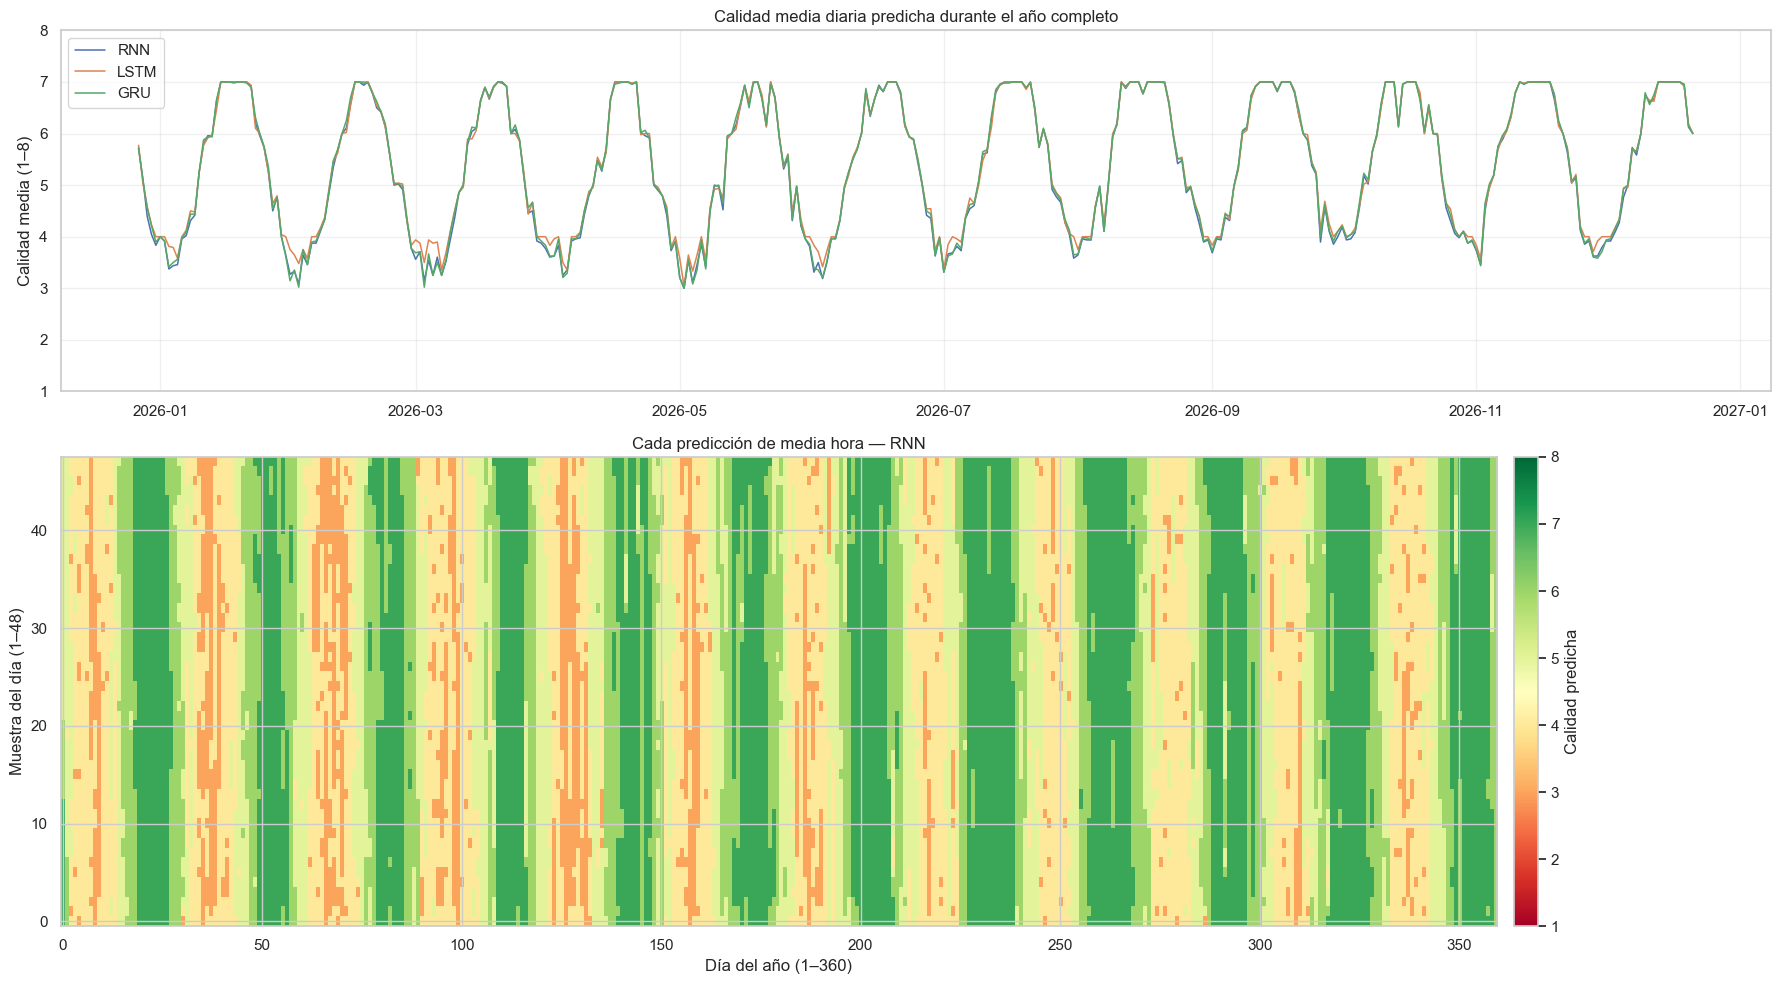

In [63]:
fechas_dias = df_anio_norm["fecha_hora"].iloc[::48].reset_index(drop=True)
calidad_diaria = pd.DataFrame({
    nombre: pred.mean(axis=1) for nombre, pred in pred_anio.items()
}, index=fechas_dias)

fig, axes = plt.subplots(2, 1, figsize=(18, 10), gridspec_kw={"height_ratios": [1, 1.3]})
for nombre in calidad_diaria.columns:
    axes[0].plot(calidad_diaria.index, calidad_diaria[nombre], linewidth=1.1, label=nombre)
axes[0].set_title("Calidad media diaria predicha durante el año completo")
axes[0].set_ylabel("Calidad media (1–8)")
axes[0].set_ylim(1, 8); axes[0].legend(); axes[0].grid(alpha=0.3)

modelo_mapa = mejor_modelo
imagen = axes[1].imshow(
    pred_anio[modelo_mapa].T, aspect="auto", origin="lower",
    cmap="RdYlGn", vmin=1, vmax=8, interpolation="nearest"
)
axes[1].set_title(f"Cada predicción de media hora — {modelo_mapa}")
axes[1].set_xlabel("Día del año (1–360)")
axes[1].set_ylabel("Muestra del día (1–48)")
barra = fig.colorbar(imagen, ax=axes[1], pad=0.01)
barra.set_label("Calidad predicha")
barra.set_ticks(range(1, 9))

plt.tight_layout(); plt.show()

### Predicción diaria completa de 2027

Para representar cada día con una sola clase, se toma la calidad más frecuente entre sus 48 predicciones de media hora. Según la convención del ejercicio, el año contiene 360 días.

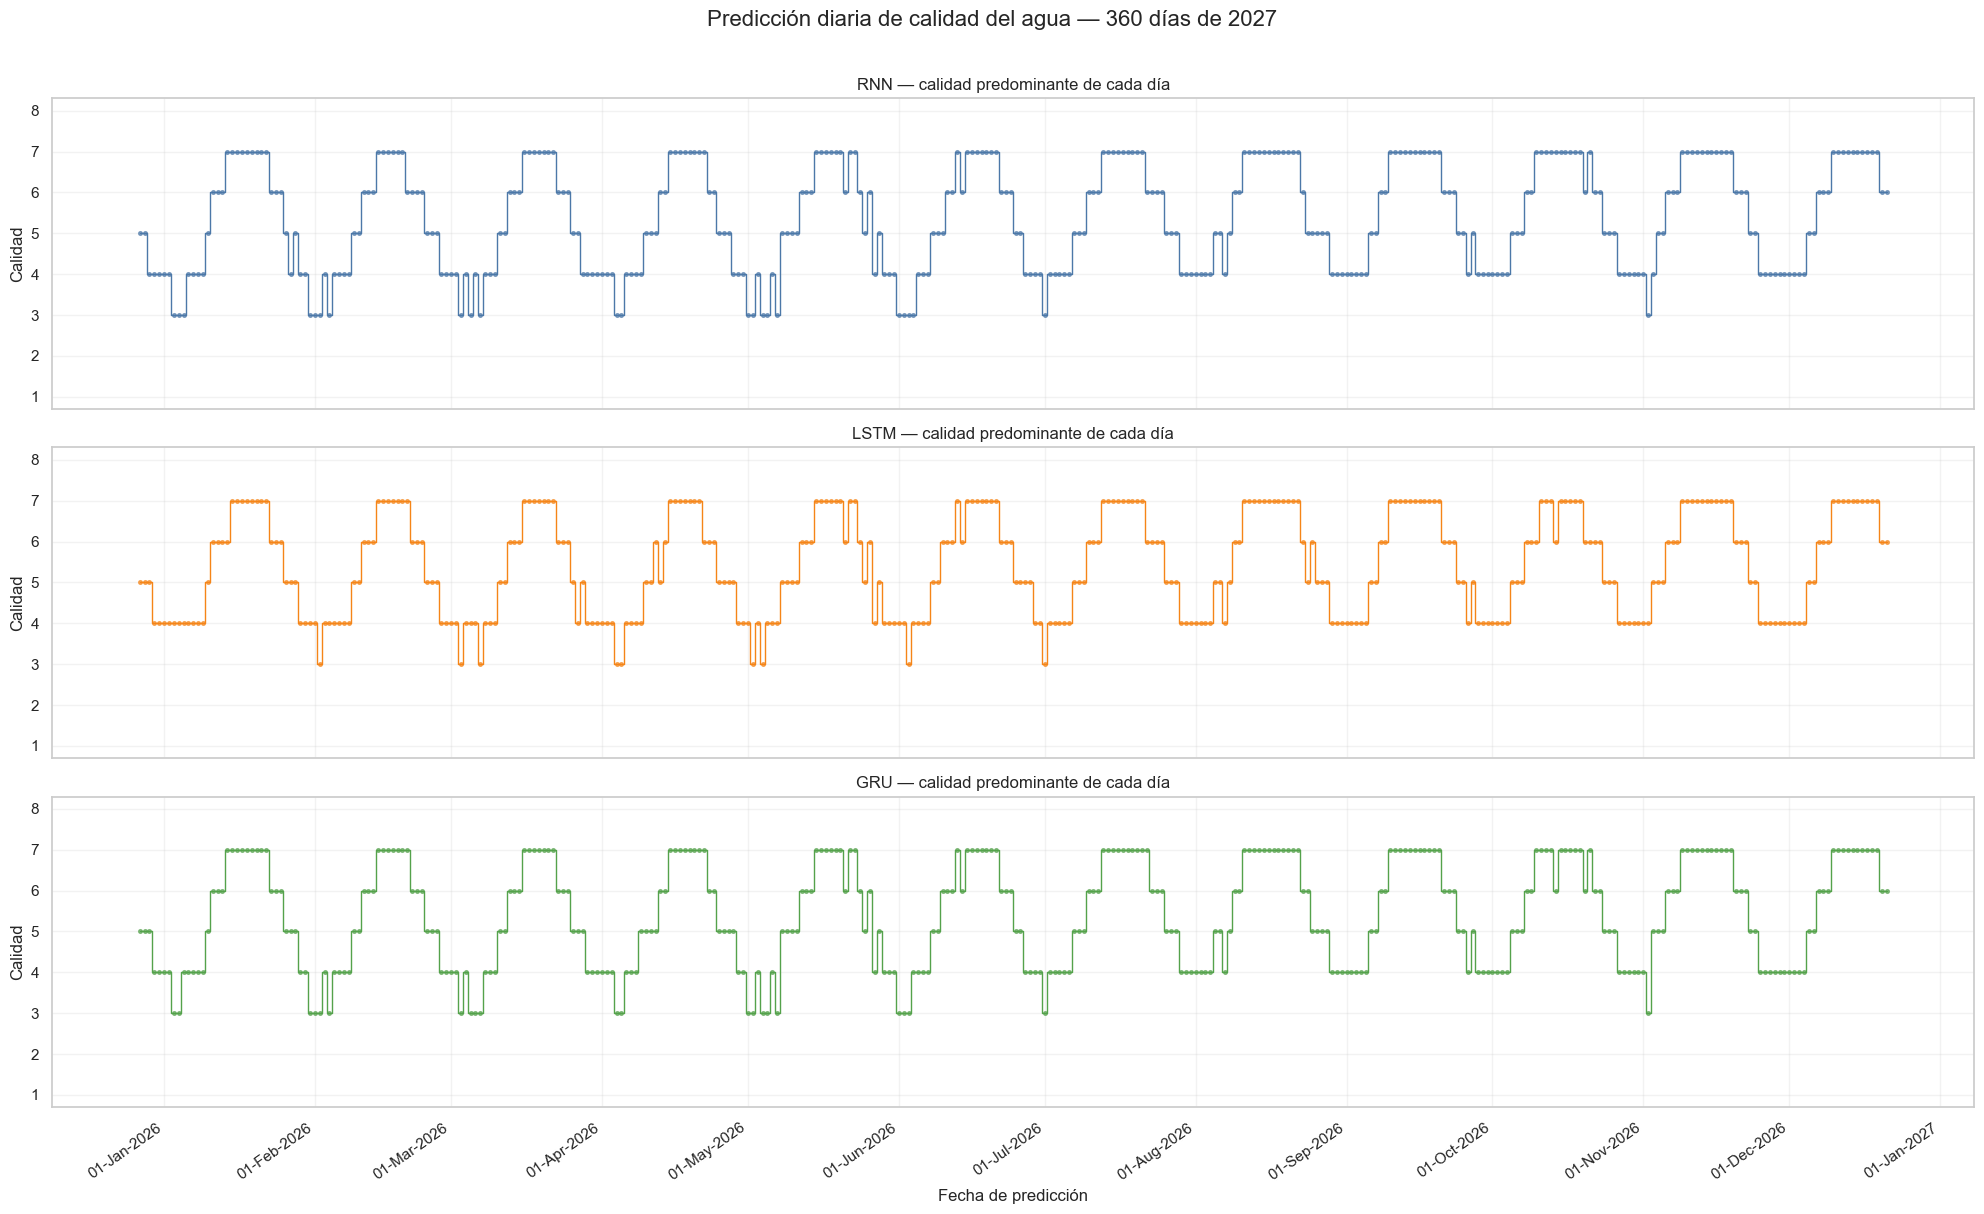

In [71]:
import matplotlib.dates as mdates

def clase_predominante_diaria(predicciones_48):
    return np.apply_along_axis(
        lambda dia: np.bincount(dia, minlength=9)[1:].argmax() + 1,
        axis=1, arr=predicciones_48
    )

prediccion_diaria_2027 = pd.DataFrame({
    nombre: clase_predominante_diaria(pred)
    for nombre, pred in pred_anio.items()
}, index=pd.DatetimeIndex(fechas_dias))

fig, axes = plt.subplots(3, 1, figsize=(20, 12), sharex=True)
colores = {"RNN": "#4C78A8", "LSTM": "#F58518", "GRU": "#54A24B"}

for ax, nombre in zip(axes, ["RNN", "LSTM", "GRU"]):
    ax.step(
        prediccion_diaria_2027.index, prediccion_diaria_2027[nombre],
        where="mid", linewidth=1.0, color=colores[nombre]
    )
    ax.scatter(
        prediccion_diaria_2027.index, prediccion_diaria_2027[nombre],
        s=7, alpha=0.65, color=colores[nombre]
    )
    ax.set_title(f"{nombre} — calidad predominante de cada día")
    ax.set_ylabel("Calidad")
    ax.set_yticks(range(1, 9)); ax.set_ylim(0.7, 8.3)
    ax.grid(alpha=0.25)

axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d-%b-%Y"))
axes[-1].set_xlabel("Fecha de predicción")
plt.setp(axes[-1].get_xticklabels(), rotation=35, ha="right")
fig.suptitle(
    "Predicción diaria de calidad del agua — 360 días de 2027",
    fontsize=16, y=1.01
)
plt.tight_layout(); plt.show()

### Predicción de 2027 mes a mes

Cada panel conserva las 1.440 predicciones del mes: 30 días en columnas y 48 mediciones de media hora en filas. No se aplica ningún promedio.

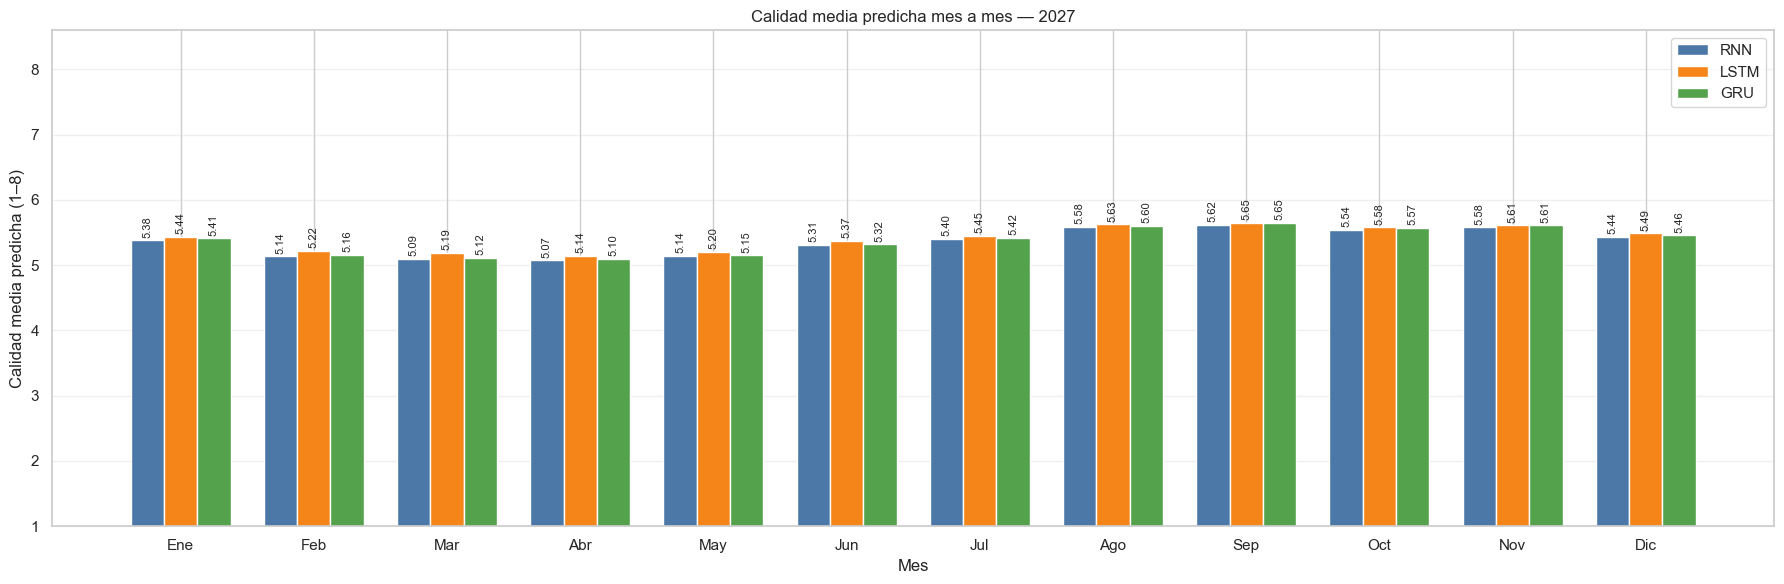

,RNN,LSTM,GRU
Ene,5.380,5.435,5.413
Feb,5.137,5.221,5.165
Mar,5.093,5.189,5.117
Abr,5.074,5.143,5.102
May,5.142,5.201,5.151
Jun,5.308,5.370,5.320
Jul,5.399,5.447,5.424
Ago,5.583,5.626,5.599
Sep,5.624,5.651,5.652
Oct,5.544,5.581,5.573


In [72]:
nombres_meses = [
    "Ene", "Feb", "Mar", "Abr", "May", "Jun",
    "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"
]

# Puedes reemplazar mejor_modelo por "RNN", "LSTM" o "GRU".
modelo_mensual = mejor_modelo
predicciones_por_mes = pred_anio[modelo_mensual].reshape(12, 30, 48)

fig, axes = plt.subplots(4, 3, figsize=(20, 18), sharex=True, sharey=True)
ultima_imagen = None

for numero_mes, (ax, nombre_mes) in enumerate(zip(axes.flat, nombres_meses)):
    # Transponer: filas = 48 momentos; columnas = 30 días.
    ultima_imagen = ax.imshow(
        predicciones_por_mes[numero_mes].T,
        aspect="auto", origin="lower", cmap="RdYlGn",
        vmin=1, vmax=8, interpolation="nearest"
    )
    ax.set_title(f"{nombre_mes} 2027")
    ax.set_xticks([0, 4, 9, 14, 19, 24, 29], [1, 5, 10, 15, 20, 25, 30])
    ax.set_yticks([0, 7, 15, 23, 31, 39, 47],
                  ["00:00", "03:30", "07:30", "11:30", "15:30", "19:30", "23:30"])
    ax.set_xlabel("Día del mes")
    ax.set_ylabel("Hora de la muestra")

barra = fig.colorbar(ultima_imagen, ax=axes, location="right", shrink=0.75, pad=0.02)
barra.set_label("Calidad predicha (1–8)")
barra.set_ticks(range(1, 9))
fig.suptitle(
    f"Todas las predicciones de 2027 mes a mes — {modelo_mensual}",
    fontsize=17, y=0.995
)
fig.subplots_adjust(left=0.07, right=0.90, top=0.95, bottom=0.05, hspace=0.28, wspace=0.18)
plt.show()